In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
import Plots as plt
using LaTeXStrings

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`


The work below and values used can be found in:
Hairer, E., Nørsett, S. P., & Wanner, G. (2008). Solving Ordinary Differential Equations I: Nonstiff Problems (2nd rev. ed.). Springer-Verlag.

In [2]:
#Parameters from 'Solving Differential Equations 1'
D = 0.1
μ = 4.0
A = 2.0
ω = π;

In [3]:
#state vector: x_vec = [y, v, time]
#Equation: v' = -2*D*v - y + A*cos(ω*time) - μ * sgn(v)

#F(x) represents the vector field when H(x) > 0 (v > 0), so sign(v) = +1
F(x_vec) = [
    x_vec[2],
    -2*D*x_vec[2] - x_vec[1] + A*cos(ω*x_vec[3]) - μ,
    1.0
]

G(x_vec) = [
    x_vec[2],
    -2*D*x_vec[2] - x_vec[1] + A*cos(ω*x_vec[3]) + μ,
    1.0
];

In [4]:
#The switching surface is where velocity v = 0
H(x_vec) = x_vec[2]
N(x_vec) = [0.0, 1.0, 0.0];

In [5]:
# Initial values fromt he book: y(0) = 3, y'(0) = 4, t(0) = 0
initial_state = [3.0, 4.0, 0.0]
tspan = (0.0, 10.0); #This tspan captures the mahor features of the example within the book

In [6]:
#Build and solve
sys = HD.FilippovSystem(F, G, H, N)
prob = HD.prob(sys, initial_state, tspan)
sol = HD.solve(prob, HD.RK45(), track_sliding=:both);

┌ Info: Sliding mode entered at t = 2.035227793631304
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Filippov.jl:270
┌ Info: Sliding mode exited at t = 2.628091819809643
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Filippov.jl:274
┌ Info: Sliding mode entered at t = 3.727466057866792
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Filippov.jl:270
┌ Info: Sliding mode exited at t = 4.684860435890436
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Filippov.jl:274
┌ Info: Sliding mode entered at t = 5.618162100605003
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Filippov.jl:270
┌ Info: Sliding mode exited at t = 6.719342134417389
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\Filippov.jl:274
┌ Info: Sliding mode entered at t = 7.551540144240177
└ @ Hyb

In [7]:
# Extrat the exact benchmark from our solution object
x1 = sol.event_times[1] # First intersection (crosses through)
x2 = sol.event_times[2] # Second intersection (enters sliding mode)
x3 = sol.event_times[3]; # First exit event (slips off sliding mode)

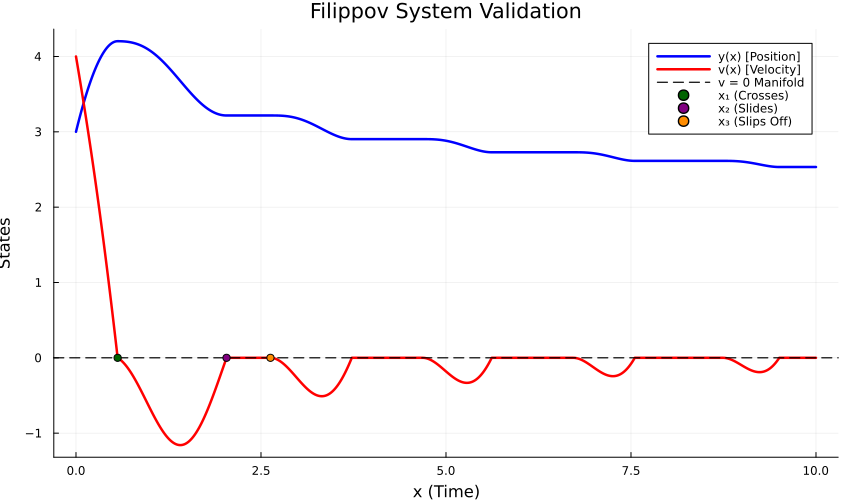

In [8]:
plot = plt.plot(sol.t, [x[1] for x in sol.x], lw=2.5, label="y(x) [Position]", color=:blue, title = "Filippov System Validation", xlabel="x (Time)", ylabel="States", size=(850, 500))
plt.plot!(plot, sol.t, [x[2] for x in sol.x], lw=2.5, label="v(x) [Velocity]", color=:red)
plt.hline!(plot, [0.0], lw=1.2, lc=:black, ls=:dash, label="v = 0 Manifold")

# We place markers at (x_i, 0.0) since they all land on the velocity manifold
plt.scatter!(plot, [x1], [0.0], ms=4, mc=:darkgreen, marker=:circle, label="x₁ (Crosses)")
plt.scatter!(plot, [x2], [0.0], ms=4, mc=:purple, marker=:circle, label="x₂ (Slides)")
plt.scatter!(plot, [x3], [0.0], ms=4, mc=:darkorange, marker=:circle, label="x₃ (Slips Off)")


In [9]:
println(" Point x1 (Crosses)   | Solver: x₁ ≈ $(round(x1, digits=6)) | Book: x₁ ≈ 0.5628 ")
println(" Point x2 (Slides)    | Solver: x₂ ≈ $(round(x2, digits=6)) | Book: x₂ ≈ 2.0352 ")
println(" Point x3 (Slips Off) | Solver: x₃ ≈ $(round(x3, digits=6)) | Book: x₃ ≈ 2.6281 ")

#Above is our validation for the values found in the book and our own calculated ones. 
# x1 is where we first cross over the v=0 manifold signifying a crossing. 
# x2 is where we hit v=0 for the second time. However we then enter a sliding mode
# x3 is where we exit this sliding mode we entered at x2. 

 Point x1 (Crosses)   | Solver: x₁ ≈ 0.562773 | Book: x₁ ≈ 0.5628 
 Point x2 (Slides)    | Solver: x₂ ≈ 2.034603 | Book: x₂ ≈ 2.0352 
 Point x3 (Slips Off) | Solver: x₃ ≈ 2.628092 | Book: x₃ ≈ 2.6281 
